# Alocador diário de recursos urbanos — exemplo mockado

Este notebook implementa o modelo descrito no README: uma única alocação no começo do dia, arestas com **tempo de deslocamento** e **estimativa de pessoas afetadas**, e penalidade $p_i t_i^2$ para demandas que permanecem abertas.

O exemplo usa 20 vértices, 31 arestas, 10 demandas e uma equipe com jornada de 8 horas. A solução é exata para estes dados: uma programação dinâmica enumera subconjuntos de demandas e encontra a melhor ordem para cada um.

## 1. Preparação

As principais decisões do experimento ficam concentradas nesta célula: semente aleatória, duração da jornada, retorno ou não à base e pesos da função objetivo.

In [1]:
from pathlib import Path
from functools import lru_cache

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)

BASE = 0
SHIFT_MINUTES = 8 * 60
RETURN_TO_BASE = False
WEIGHTS = {"aging": 0.55, "priority": 0.20, "people": 0.25}

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
print("Configuração:", {"jornada_min": SHIFT_MINUTES, "retorno_base": RETURN_TO_BASE, **WEIGHTS})

Configuração: {'jornada_min': 480, 'retorno_base': False, 'aging': 0.55, 'priority': 0.2, 'people': 0.25}


## 2. Grafo e demandas mockadas

A cidade é uma malha $4\times5$. Cada aresta recebe exatamente as duas propriedades do modelo:

- `travel_min`: minutos necessários para atravessá-la;
- `affected_people`: pessoas estimadas como afetadas caso uma demanda naquela aresta seja atendida.

Para manter o exemplo simples, cada demanda possui um vértice de acesso em uma das extremidades de sua aresta.

In [2]:
# Cria uma grade com 20 vértices e converte as coordenadas em IDs inteiros.
grid = nx.grid_2d_graph(4, 5)
node_map = {node: i for i, node in enumerate(sorted(grid.nodes()))}
G = nx.relabel_nodes(grid, node_map)
pos = {node_map[(row, col)]: (col, -row) for row, col in grid.nodes()}

# Duas propriedades por aresta: tempo e pessoas afetadas.
for u, v in G.edges():
    G[u][v]["travel_min"] = int(rng.integers(4, 13))
    G[u][v]["affected_people"] = int(rng.integers(80, 1001))

# Dez demandas em arestas distintas.
candidate_edges = list(G.edges())
chosen_positions = rng.choice(len(candidate_edges), size=10, replace=False)
demands = []
for demand_number, edge_position in enumerate(chosen_positions, start=1):
    u, v = candidate_edges[int(edge_position)]
    access_node = int(rng.choice([u, v]))
    priority = int(rng.integers(1, 6))
    age_days = int(rng.integers(1, 16))
    service_min = int(rng.integers(35, 101))
    demands.append({
        "id": f"D{demand_number}",
        "edge": (u, v),
        "access_node": access_node,
        "priority": priority,
        "age_days": age_days,
        "service_min": service_min,
        "affected_people": G[u][v]["affected_people"],
        "aging_penalty": priority * age_days**2,
    })

demands_df = pd.DataFrame(demands)
demands_df["edge"] = demands_df["edge"].map(lambda e: f"{e[0]}–{e[1]}")
demands_df

,id,edge,access_node,priority,age_days,service_min,affected_people,aging_penalty
0,D1,4–9,4,1,13,76,197,169
1,D2,2–3,3,1,5,85,978,25
2,D3,1–6,6,3,13,90,870,507
3,D4,5–10,5,5,5,50,494,125
4,D5,7–12,12,4,3,89,837,36
5,D6,17–18,17,5,1,87,709,5
6,D7,13–18,18,4,10,66,796,400
7,D8,5–6,6,2,12,71,421,288
8,D9,12–17,12,3,9,37,974,243
9,D10,12–13,12,2,2,64,902,8


## 3. Imagem do grafo

A espessura das ruas representa o tempo de deslocamento. A cor representa a estimativa de pessoas afetadas; os círculos laranja identificam as dez demandas.

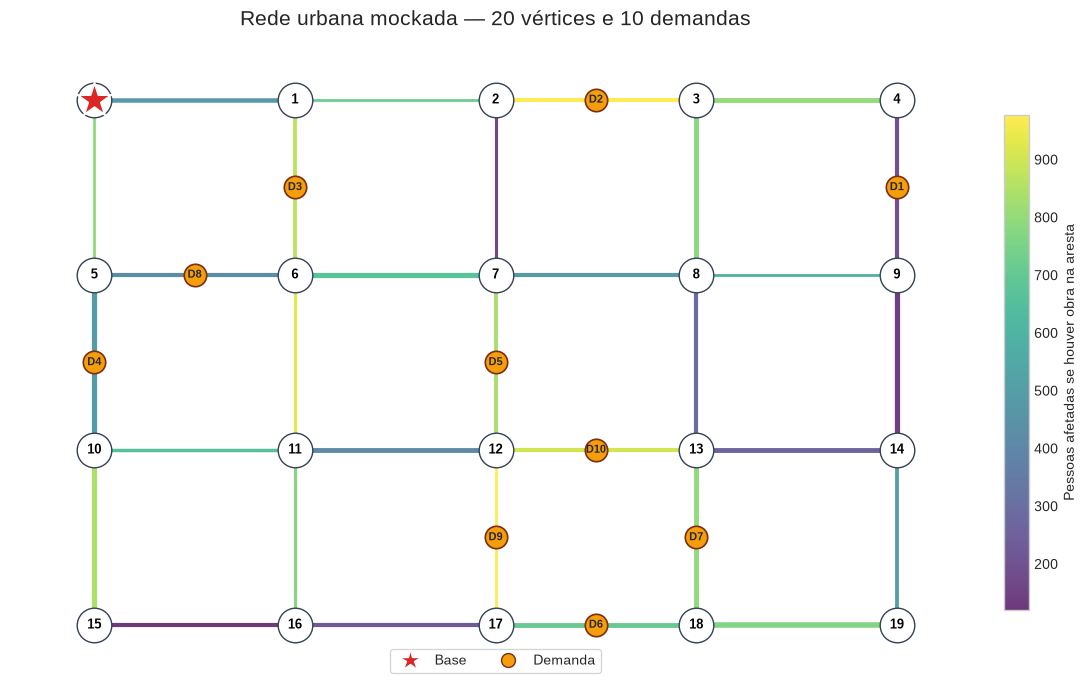

In [3]:
fig, ax = plt.subplots(figsize=(12, 7))
edge_people = np.array([G[u][v]["affected_people"] for u, v in G.edges()])
edge_times = np.array([G[u][v]["travel_min"] for u, v in G.edges()])

edges_artist = nx.draw_networkx_edges(
    G, pos, ax=ax, edge_color=edge_people, edge_cmap=plt.cm.viridis,
    edge_vmin=edge_people.min(), edge_vmax=edge_people.max(),
    width=1.0 + edge_times / 4.0, alpha=0.78
)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="white", edgecolors="#334155", node_size=620)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")

for demand in demands:
    u, v = demand["edge"]
    midpoint = ((pos[u][0] + pos[v][0]) / 2, (pos[u][1] + pos[v][1]) / 2)
    ax.scatter(*midpoint, s=260, color="#f59e0b", edgecolor="#7c2d12", linewidth=1.2, zorder=5)
    ax.text(*midpoint, demand["id"], ha="center", va="center", fontsize=8, fontweight="bold", zorder=6)

ax.scatter(*pos[BASE], marker="*", s=650, color="#dc2626", edgecolor="white", linewidth=1.4, zorder=7)
ax.set_title("Rede urbana mockada — 20 vértices e 10 demandas", fontsize=15, pad=14)
ax.set_axis_off()
cbar = fig.colorbar(edges_artist, ax=ax, shrink=0.78, pad=0.02)
cbar.set_label("Pessoas afetadas se houver obra na aresta")
legend = [
    Line2D([0], [0], marker="*", color="w", label="Base", markerfacecolor="#dc2626", markersize=16),
    Line2D([0], [0], marker="o", color="w", label="Demanda", markerfacecolor="#f59e0b", markeredgecolor="#7c2d12", markersize=10),
]
ax.legend(handles=legend, loc="lower center", ncol=2, frameon=True)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "grafo_mock.png", dpi=170, bbox_inches="tight")
plt.show()

## 4. Função objetivo

Para uma rota $R$, maximizamos:

$$J(R)=-w_A\frac{\sum_i p_i t_i^2(1-x_i)}{A_{\mathrm{total}}}+w_P\frac{\sum_i p_i x_i}{P_{\mathrm{total}}}-w_N\frac{\sum_i n_{e_i}x_i}{N_{\mathrm{total}}}.$$

A primeira parcela penaliza demandas prioritárias e antigas que ficam abertas; a segunda recompensa prioridades atendidas; a terceira penaliza o número de pessoas impactadas. Portanto, valores maiores de $J$ são melhores. Deslocamento e serviço participam da restrição de jornada, mas não da função objetivo.

In [4]:
# Matriz de menores tempos entre a base e os pontos de acesso das demandas.
stops = [BASE] + [d["access_node"] for d in demands]
travel = np.zeros((len(stops), len(stops)), dtype=float)
for i, source in enumerate(stops):
    lengths = nx.single_source_dijkstra_path_length(G, source, weight="travel_min")
    for j, target in enumerate(stops):
        travel[i, j] = lengths[target]

n = len(demands)
all_mask = (1 << n) - 1
service = np.array([d["service_min"] for d in demands], dtype=float)
penalties = np.array([d["aging_penalty"] for d in demands], dtype=float)
priorities = np.array([d["priority"] for d in demands], dtype=float)
people = np.array([d["affected_people"] for d in demands], dtype=float)
penalty_ref = penalties.sum()
priority_ref = priorities.sum()
people_ref = people.sum()

@lru_cache(maxsize=None)
def subset_sum(mask, values_tuple):
    return sum(values_tuple[i] for i in range(n) if mask & (1 << i))

service_tuple = tuple(service)
penalty_tuple = tuple(penalties)
priority_tuple = tuple(priorities)
people_tuple = tuple(people)

# Held–Karp: dp[(máscara, última demanda)] = menor deslocamento até esse estado.
dp = {}
parent = {}
for j in range(n):
    mask = 1 << j
    dp[(mask, j)] = travel[0, j + 1]
    parent[(mask, j)] = None

for mask in range(1, all_mask + 1):
    for last in range(n):
        state = (mask, last)
        if state not in dp:
            continue
        current_travel = dp[state]
        for nxt in range(n):
            if mask & (1 << nxt):
                continue
            new_mask = mask | (1 << nxt)
            candidate = current_travel + travel[last + 1, nxt + 1]
            new_state = (new_mask, nxt)
            if candidate < dp.get(new_state, np.inf):
                dp[new_state] = candidate
                parent[new_state] = last

def evaluate(mask, route_travel):
    selected_service = subset_sum(mask, service_tuple)
    total_time = route_travel + selected_service
    if total_time > SHIFT_MINUTES:
        return None
    open_penalty = penalty_ref - subset_sum(mask, penalty_tuple)
    selected_priority = subset_sum(mask, priority_tuple)
    selected_people = subset_sum(mask, people_tuple)
    components = {
        "aging": -WEIGHTS["aging"] * open_penalty / penalty_ref,
        "priority": WEIGHTS["priority"] * selected_priority / priority_ref,
        "people": -WEIGHTS["people"] * selected_people / people_ref,
    }
    return sum(components.values()), components, total_time

# A rota vazia também é candidata.
empty_eval = evaluate(0, 0.0)
best = {"mask": 0, "last": None, "travel": 0.0, "evaluation": empty_eval}

for (mask, last), outward_travel in dp.items():
    route_travel = outward_travel + (travel[last + 1, 0] if RETURN_TO_BASE else 0.0)
    evaluation = evaluate(mask, route_travel)
    if evaluation is not None and evaluation[0] > best["evaluation"][0]:
        best = {"mask": mask, "last": last, "travel": route_travel, "evaluation": evaluation}

# Reconstrói a ordem ótima.
order = []
mask, last = best["mask"], best["last"]
while last is not None:
    order.append(last)
    previous = parent[(mask, last)]
    mask ^= 1 << last
    last = previous
order.reverse()
selected = set(order)

print(f"Valor ótimo (maior é melhor): {best['evaluation'][0]:.4f}")
print("Ordem:", " → ".join(demands[i]["id"] for i in order) or "rota vazia")
print(f"Demandas selecionadas: {len(order)}/{n}")
print(f"Deslocamento: {best['travel']:.0f} min")
print(f"Tempo total: {best['evaluation'][2]:.0f}/{SHIFT_MINUTES} min")

Valor ótimo (maior é melhor): -0.0332
Ordem: D4 → D8 → D3 → D1 → D7 → D9
Demandas selecionadas: 6/10
Deslocamento: 85 min
Tempo total: 475/480 min


## 5. Cronograma da rota escolhida

In [5]:
def clock(minutes_after_start, start_hour=8):
    absolute = start_hour * 60 + int(round(minutes_after_start))
    return f"{absolute // 60:02d}:{absolute % 60:02d}"

schedule = []
elapsed = 0.0
previous_stop_index = 0
for position, demand_index in enumerate(order, start=1):
    leg = travel[previous_stop_index, demand_index + 1]
    elapsed += leg
    arrival = elapsed
    elapsed += demands[demand_index]["service_min"]
    schedule.append({
        "ordem": position,
        "demanda": demands[demand_index]["id"],
        "prioridade": demands[demand_index]["priority"],
        "idade_dias": demands[demand_index]["age_days"],
        "p_t2": demands[demand_index]["aging_penalty"],
        "pessoas_afetadas": demands[demand_index]["affected_people"],
        "deslocamento_min": int(leg),
        "chegada": clock(arrival),
        "término": clock(elapsed),
    })
    previous_stop_index = demand_index + 1

if RETURN_TO_BASE and order:
    elapsed += travel[previous_stop_index, 0]

schedule_df = pd.DataFrame(schedule)
schedule_df

,ordem,demanda,prioridade,idade_dias,p_t2,pessoas_afetadas,deslocamento_min,chegada,término
0,1,D4,5,5,125,494,4,08:04,08:54
1,2,D8,2,12,288,421,8,09:02,10:13
2,3,D3,3,13,507,870,0,10:13,11:43
3,4,D1,1,13,169,197,29,12:12,13:28
4,5,D7,4,10,400,796,30,13:58,15:04
5,6,D9,3,9,243,974,14,15:18,15:55


In [6]:
# Indicadores e decomposição do objetivo.
selected_penalty = penalties[list(selected)].sum() if selected else 0
selected_priority = priorities[list(selected)].sum() if selected else 0
selected_people = people[list(selected)].sum() if selected else 0
open_penalty = penalty_ref - selected_penalty
components = best["evaluation"][1]

summary_df = pd.DataFrame([
    {"indicador": "Demandas atendidas", "valor": f"{len(selected)} de {n}"},
    {"indicador": "Penalidade evitada", "valor": f"{selected_penalty:.0f} de {penalty_ref:.0f}"},
    {"indicador": "Penalidade ainda aberta", "valor": f"{open_penalty:.0f}"},
    {"indicador": "Prioridade atendida", "valor": f"{selected_priority:.0f} de {priority_ref:.0f}"},
    {"indicador": "Pessoas afetadas", "valor": f"{selected_people:.0f}"},
    {"indicador": "Tempo de deslocamento", "valor": f"{best['travel']:.0f} min"},
    {"indicador": "Tempo total da rota", "valor": f"{best['evaluation'][2]:.0f} min"},
    {"indicador": "Função objetivo", "valor": f"{best['evaluation'][0]:.4f}"},
])
summary_df

,indicador,valor
0,Demandas atendidas,6 de 10
1,Penalidade evitada,1732 de 1806
2,Penalidade ainda aberta,74
3,Prioridade atendida,18 de 30
4,Pessoas afetadas,3752
5,Tempo de deslocamento,85 min
6,Tempo total da rota,475 min
7,Função objetivo,-0.0332


## 6. Imagem da rota ótima

A linha azul mostra o caminho percorrido. Demandas verdes são atendidas, demandas vermelhas ficam abertas e os números verdes indicam a ordem de execução.

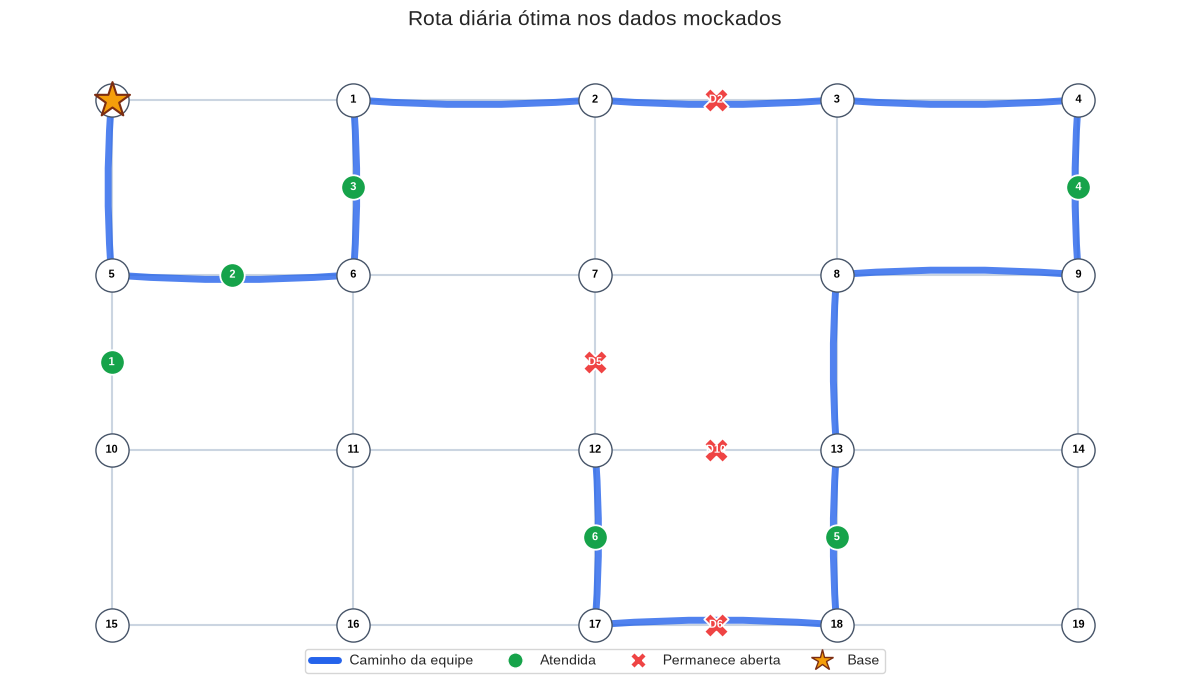

In [7]:
# Expande a sequência de pontos de atendimento para caminhos reais no grafo.
route_nodes = [BASE]
for demand_index in order:
    target = demands[demand_index]["access_node"]
    segment = nx.shortest_path(G, route_nodes[-1], target, weight="travel_min")
    route_nodes.extend(segment[1:])
if RETURN_TO_BASE and route_nodes[-1] != BASE:
    segment = nx.shortest_path(G, route_nodes[-1], BASE, weight="travel_min")
    route_nodes.extend(segment[1:])
route_edges = list(zip(route_nodes[:-1], route_nodes[1:]))

fig, ax = plt.subplots(figsize=(12, 7))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#cbd5e1", width=1.5)
if route_edges:
    nx.draw_networkx_edges(
        G, pos, ax=ax, edgelist=route_edges, edge_color="#2563eb",
        width=5, alpha=0.8, arrows=True, arrowsize=18, connectionstyle="arc3,rad=0.04"
    )
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="white", edgecolors="#475569", node_size=570)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight="bold")

for i, demand in enumerate(demands):
    u, v = demand["edge"]
    midpoint = ((pos[u][0] + pos[v][0]) / 2, (pos[u][1] + pos[v][1]) / 2)
    is_selected = i in selected
    color = "#16a34a" if is_selected else "#ef4444"
    marker = "o" if is_selected else "X"
    ax.scatter(*midpoint, s=310, marker=marker, color=color, edgecolor="white", linewidth=1.3, zorder=6)
    label = str(order.index(i) + 1) if is_selected else demand["id"]
    ax.text(*midpoint, label, ha="center", va="center", color="white", fontsize=8, fontweight="bold", zorder=7)

ax.scatter(*pos[BASE], marker="*", s=700, color="#f59e0b", edgecolor="#7c2d12", linewidth=1.5, zorder=8)
ax.set_title("Rota diária ótima nos dados mockados", fontsize=15, pad=14)
ax.set_axis_off()
legend = [
    Line2D([0], [0], color="#2563eb", lw=5, label="Caminho da equipe"),
    Line2D([0], [0], marker="o", color="w", label="Atendida", markerfacecolor="#16a34a", markersize=11),
    Line2D([0], [0], marker="X", color="w", label="Permanece aberta", markerfacecolor="#ef4444", markersize=11),
    Line2D([0], [0], marker="*", color="w", label="Base", markerfacecolor="#f59e0b", markeredgecolor="#7c2d12", markersize=16),
]
ax.legend(handles=legend, loc="lower center", ncol=4, frameon=True)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "rota_otima.png", dpi=170, bbox_inches="tight")
plt.show()

## 7. Decomposição do objetivo

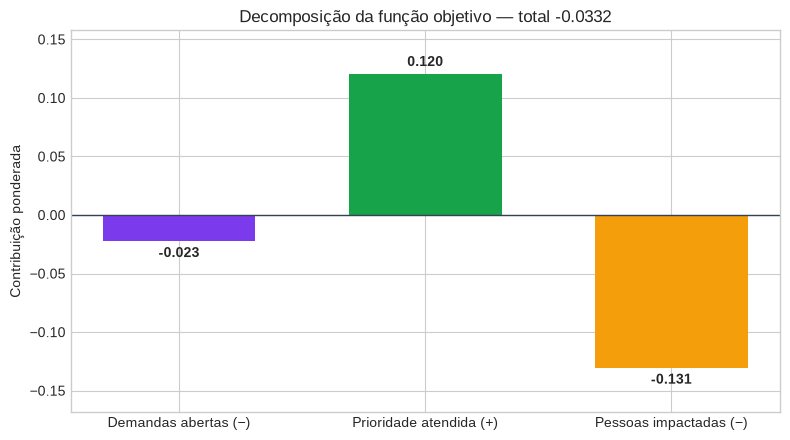

In [8]:
labels = ["Demandas abertas (−)", "Prioridade atendida (+)", "Pessoas impactadas (−)"]
values = [components["aging"], components["priority"], components["people"]]
colors = ["#7c3aed", "#16a34a", "#f59e0b"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, values, color=colors, width=0.62)
ax.bar_label(bars, fmt="%.3f", padding=4, fontweight="bold")
ax.axhline(0, color="#334155", linewidth=1)
ax.set_ylabel("Contribuição ponderada")
ax.set_title(f"Decomposição da função objetivo — total {sum(values):.4f}")
margin = max(max(values) - min(values), 0.1) * 0.15
ax.set_ylim(min(values) - margin, max(values) + margin)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "componentes_objetivo.png", dpi=170, bbox_inches="tight")
plt.show()

## 8. Comparação com algoritmos heurísticos

A programação dinâmica encontra o ótimo global nesta instância porque avalia todos os subconjuntos e a menor rota de cada subconjunto. A comparação usa os mesmos dados e a mesma restrição para quatro abordagens:

- **Ótimo exato:** programação dinâmica Held–Karp;
- **Guloso por ganho/minuto:** escolhe o maior ganho marginal do objetivo por minuto adicional;
- **Guloso por prioridade:** tenta demandas da maior para a menor prioridade;
- **Vizinho mais próximo:** sempre tenta a demanda viável mais próxima;
- **Aleatório:** constrói 1.000 rotas a partir de permutações aleatórias.

Isso prova a superioridade do método exato **para estes dados mockados**. Para sustentar uma conclusão geral, o experimento deve ser repetido em muitas instâncias e com tempos de execução também registrados.

In [9]:
def evaluate_order(candidate_order):
    """Avalia uma ordem explícita com a mesma função e restrição do ótimo."""
    if len(candidate_order) != len(set(candidate_order)):
        raise ValueError("Uma demanda não pode aparecer duas vezes.")
    mask = 0
    route_travel = 0.0
    previous_stop = 0
    for demand_index in candidate_order:
        route_travel += travel[previous_stop, demand_index + 1]
        previous_stop = demand_index + 1
        mask |= 1 << demand_index
    if RETURN_TO_BASE and candidate_order:
        route_travel += travel[previous_stop, 0]
    evaluation = evaluate(mask, route_travel)
    if evaluation is None:
        return None
    score, score_components, total_time = evaluation
    return {
        "order": list(candidate_order), "mask": mask, "score": score,
        "components": score_components, "travel": route_travel,
        "total_time": total_time,
    }

def greedy_priority():
    ranking = sorted(range(n), key=lambda i: (priorities[i], penalties[i]), reverse=True)
    chosen = []
    for i in ranking:
        if evaluate_order(chosen + [i]) is not None:
            chosen.append(i)
    return evaluate_order(chosen)

def marginal_gain(i):
    # Ao selecionar i, evitamos sua penalidade, ganhamos prioridade e causamos impacto.
    return (
        WEIGHTS["aging"] * penalties[i] / penalty_ref
        + WEIGHTS["priority"] * priorities[i] / priority_ref
        - WEIGHTS["people"] * people[i] / people_ref
    )

def greedy_marginal_per_minute():
    chosen, remaining = [], set(range(n))
    while remaining:
        current_stop = 0 if not chosen else chosen[-1] + 1
        candidates = []
        for i in remaining:
            trial = evaluate_order(chosen + [i])
            if trial is None or marginal_gain(i) <= 0:
                continue
            added_minutes = travel[current_stop, i + 1] + service[i]
            candidates.append((marginal_gain(i) / added_minutes, marginal_gain(i), i))
        if not candidates:
            break
        _, _, selected_i = max(candidates)
        chosen.append(selected_i)
        remaining.remove(selected_i)
    return evaluate_order(chosen)

def greedy_nearest_neighbor():
    chosen, remaining = [], set(range(n))
    while remaining:
        current_stop = 0 if not chosen else chosen[-1] + 1
        feasible = [i for i in remaining if evaluate_order(chosen + [i]) is not None]
        if not feasible:
            break
        selected_i = min(feasible, key=lambda i: (travel[current_stop, i + 1], -priorities[i]))
        chosen.append(selected_i)
        remaining.remove(selected_i)
    return evaluate_order(chosen)

exact_result = evaluate_order(order)
heuristic_results = {
    "Ótimo exato": exact_result,
    "Guloso ganho/min": greedy_marginal_per_minute(),
    "Guloso prioridade": greedy_priority(),
    "Vizinho mais próximo": greedy_nearest_neighbor(),
}

benchmark_rng = np.random.default_rng(2026)
random_results = []
for _ in range(1_000):
    random_order = []
    for i in benchmark_rng.permutation(n):
        if evaluate_order(random_order + [int(i)]) is not None:
            random_order.append(int(i))
    random_results.append(evaluate_order(random_order))

comparison_rows = []
for algorithm, result in heuristic_results.items():
    comparison_rows.append({
        "algoritmo": algorithm,
        "objetivo": result["score"],
        "gap_para_otimo": exact_result["score"] - result["score"],
        "demandas": len(result["order"]),
        "deslocamento_min": result["travel"],
        "tempo_total_min": result["total_time"],
        "ordem": " → ".join(demands[i]["id"] for i in result["order"]),
    })
comparison_df = pd.DataFrame(comparison_rows).sort_values("objetivo", ascending=False).reset_index(drop=True)

best_competitor = comparison_df.loc[comparison_df["algoritmo"] != "Ótimo exato", "objetivo"].max()
assert exact_result["score"] + 1e-12 >= best_competitor
comparison_df

,algoritmo,objetivo,gap_para_otimo,demandas,deslocamento_min,tempo_total_min,ordem
0,Ótimo exato,-0.033213,0.000000,6,85.0,475.0,D4 → D8 → D3 → D1 → D7 → D9
1,Guloso ganho/min,-0.084486,0.051273,5,77.0,391.0,D3 → D7 → D9 → D8 → D4
2,Guloso prioridade,-0.212303,0.179090,5,69.0,451.0,D4 → D6 → D7 → D5 → D3
3,Vizinho mais próximo,-0.212412,0.179199,6,27.0,428.0,D4 → D3 → D8 → D5 → D9 → D10


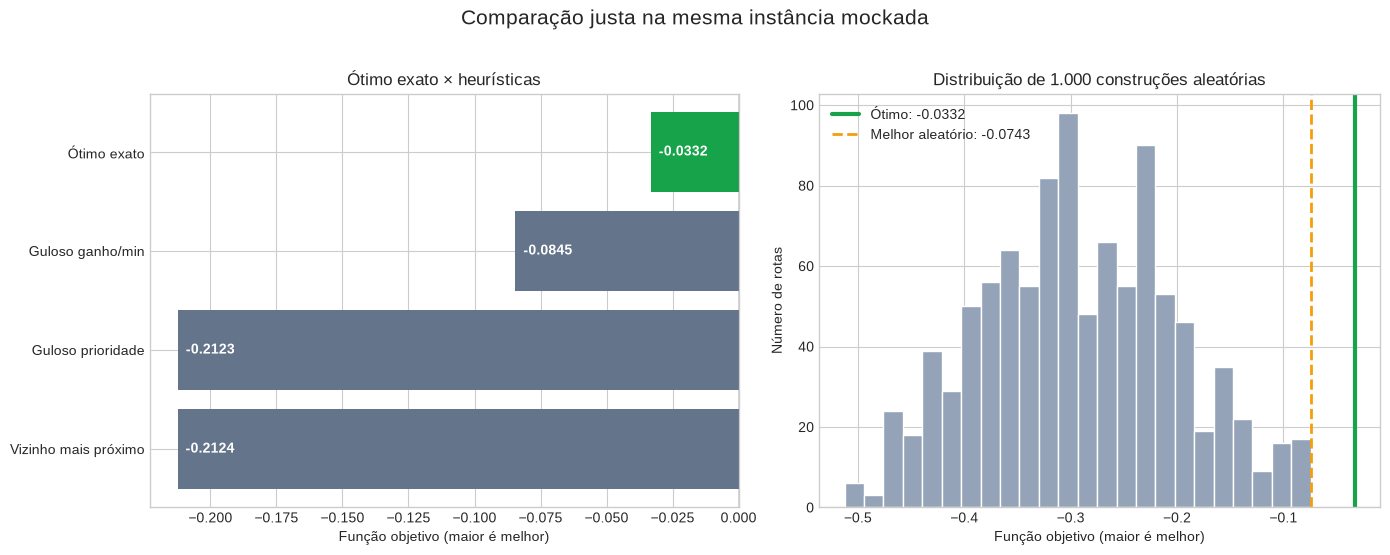

In [10]:
random_scores = np.array([result["score"] for result in random_results])
plot_df = comparison_df.sort_values("objetivo", ascending=True)
bar_colors = ["#16a34a" if name == "Ótimo exato" else "#64748b" for name in plot_df["algoritmo"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={"width_ratios": [1.05, 1]})
bars = axes[0].barh(plot_df["algoritmo"], plot_df["objetivo"], color=bar_colors)
for bar, value in zip(bars, plot_df["objetivo"]):
    if value < 0:
        axes[0].text(value + 0.003, bar.get_y() + bar.get_height() / 2, f"{value:.4f}", ha="left", va="center", color="white", fontweight="bold")
    else:
        axes[0].text(value + 0.0015, bar.get_y() + bar.get_height() / 2, f"{value:.4f}", ha="left", va="center", color="#1e293b", fontweight="bold")
axes[0].axvline(0, color="#334155", linewidth=1)
axes[0].set_xlabel("Função objetivo (maior é melhor)")
axes[0].set_title("Ótimo exato × heurísticas")

axes[1].hist(random_scores, bins=24, color="#94a3b8", edgecolor="white")
axes[1].axvline(exact_result["score"], color="#16a34a", linewidth=3, label=f"Ótimo: {exact_result['score']:.4f}")
axes[1].axvline(random_scores.max(), color="#f59e0b", linewidth=2, linestyle="--", label=f"Melhor aleatório: {random_scores.max():.4f}")
axes[1].set_xlabel("Função objetivo (maior é melhor)")
axes[1].set_ylabel("Número de rotas")
axes[1].set_title("Distribuição de 1.000 construções aleatórias")
axes[1].legend()

fig.suptitle("Comparação justa na mesma instância mockada", fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "comparacao_algoritmos.png", dpi=170, bbox_inches="tight")
plt.show()

## 9. Como experimentar

Altere `WEIGHTS`, `SHIFT_MINUTES` ou `RETURN_TO_BASE` na primeira célula e execute todas as células novamente. Como há apenas dez demandas, a programação dinâmica avalia a solução exata rapidamente. Para dezenas de demandas, seria necessário substituir a enumeração por programação inteira ou uma heurística.

## 10. Métricas concretas da solução

O painel abaixo compara os resultados operacionais da rota ótima, das três heurísticas e da melhor entre as 1.000 rotas aleatórias. **Prioridade atendida** é a soma dos pontos de prioridade das demandas selecionadas, $\sum_i p_i x_i$, conforme a função objetivo. **Maior espera não atendida** é a idade, em dias, da demanda aberta mais antiga que ficou fora da rota; o valor é zero quando todas as demandas são atendidas.

,obras_atendidas,prioridade_atendida,pessoas_afetadas,maior_espera_nao_atendida_dias
algoritmo,,,,
Ótimo exato,6,18,3752,5
Guloso ganho/min,5,17,3555,13
Guloso prioridade,5,21,3706,13
Vizinho mais próximo,6,19,4498,13
Melhor aleatória,6,22,4264,13


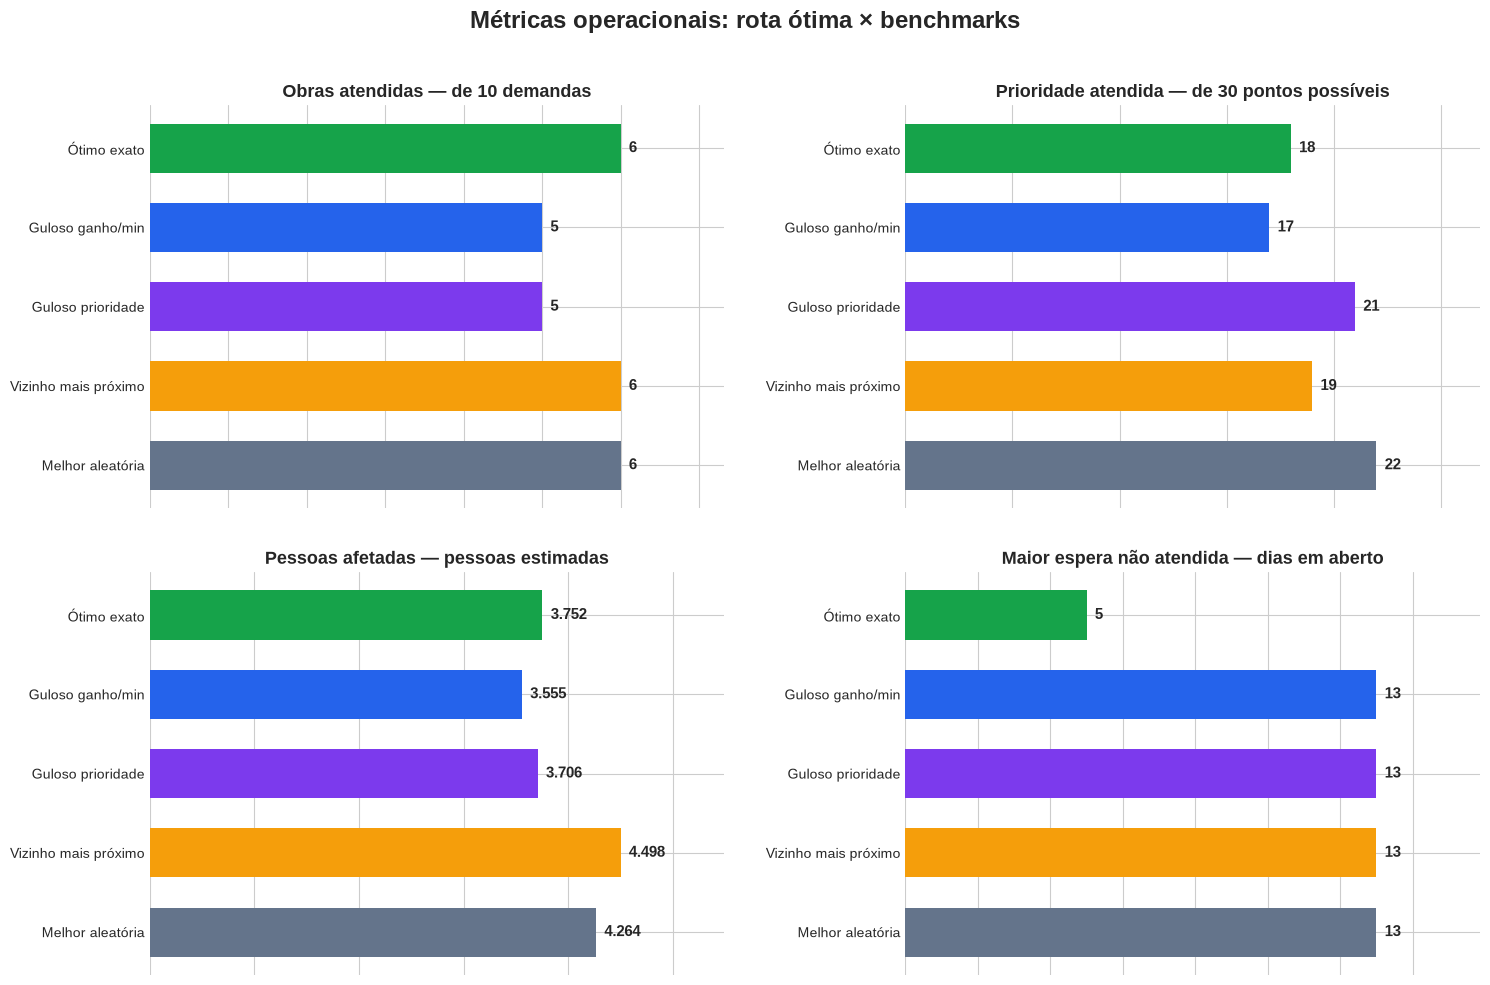

In [11]:
best_random_result = max(random_results, key=lambda result: result["score"])
benchmark_routes = {
    **heuristic_results,
    "Melhor aleatória": best_random_result,
}

operational_rows = []
for algorithm, result in benchmark_routes.items():
    attended = set(result["order"])
    unattended = set(range(n)) - attended
    operational_rows.append({
        "algoritmo": algorithm,
        "obras_atendidas": len(attended),
        "prioridade_atendida": int(sum(demands[i]["priority"] for i in attended)),
        "pessoas_afetadas": int(sum(demands[i]["affected_people"] for i in attended)),
        "maior_espera_nao_atendida_dias": max(
            (demands[i]["age_days"] for i in unattended), default=0
        ),
    })

operational_df = pd.DataFrame(operational_rows).set_index("algoritmo")
display(operational_df)

metric_specs = [
    ("obras_atendidas", "Obras atendidas", f"de {n} demandas"),
    ("prioridade_atendida", "Prioridade atendida", f"de {int(priority_ref)} pontos possíveis"),
    ("pessoas_afetadas", "Pessoas afetadas", "pessoas estimadas"),
    ("maior_espera_nao_atendida_dias", "Maior espera não atendida", "dias em aberto"),
]
algorithm_colors = ["#16a34a", "#2563eb", "#7c3aed", "#f59e0b", "#64748b"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (column, title, unit) in zip(axes.flat, metric_specs):
    values = operational_df[column]
    bars = ax.barh(values.index, values.values, color=algorithm_colors, height=0.62)
    labels = [f"{value:,.0f}".replace(",", ".") for value in values]
    ax.bar_label(bars, labels=labels, padding=6, fontsize=11, fontweight="bold")
    ax.set_xlim(0, max(float(values.max()) * 1.22, 1))
    ax.set_title(f"{title} — {unit}", fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", bottom=False, labelbottom=False)
    ax.tick_params(axis="y", labelsize=10)
    ax.invert_yaxis()
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("Métricas operacionais: rota ótima × benchmarks", fontsize=17, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96], h_pad=3.0, w_pad=3.0)
fig.savefig(OUTPUT_DIR / "metricas_concretas.png", dpi=170, bbox_inches="tight")
plt.show()

## 11. Experimentos com diferentes pontos de demanda

Um único cenário pode favorecer ou prejudicar uma política por acaso. Por isso, o experimento abaixo cria 30 novas instâncias. Em cada uma, dez arestas distintas recebem demandas com novos pontos de acesso, prioridades, idades e durações. A rede, a jornada e a interpretação das métricas permanecem iguais.

Mantemos uma única configuração de pesos em todos os cenários e comparamos três resultados: **maior espera não atendida**, **prioridade total atendida** e **pessoas afetadas**. Os pesos fixos foram calibrados para equilibrar esses critérios: 0,55 para envelhecimento, 0,20 para prioridade e 0,25 para impacto populacional.

In [12]:
N_SCENARIOS = 30
SCENARIO_SEEDS = range(100, 100 + N_SCENARIOS)
def generate_scenario(seed):
    scenario_rng = np.random.default_rng(seed)
    selected_edges = scenario_rng.choice(len(candidate_edges), size=10, replace=False)
    scenario_demands = []
    for demand_number, edge_position in enumerate(selected_edges, start=1):
        u, v = candidate_edges[int(edge_position)]
        priority = int(scenario_rng.integers(1, 6))
        age_days = int(scenario_rng.integers(1, 16))
        scenario_demands.append({
            "id": f"D{demand_number}",
            "edge": (u, v),
            "access_node": int(scenario_rng.choice([u, v])),
            "priority": priority,
            "age_days": age_days,
            "service_min": int(scenario_rng.integers(35, 101)),
            "affected_people": G[u][v]["affected_people"],
            "aging_penalty": priority * age_days**2,
        })
    return scenario_demands

def solve_scenario(scenario_demands, weights, method="exact"):
    scenario_n = len(scenario_demands)
    scenario_stops = [BASE] + [d["access_node"] for d in scenario_demands]
    scenario_travel = np.zeros((scenario_n + 1, scenario_n + 1), dtype=float)
    for source_index, source in enumerate(scenario_stops):
        lengths = nx.single_source_dijkstra_path_length(G, source, weight="travel_min")
        for target_index, target in enumerate(scenario_stops):
            scenario_travel[source_index, target_index] = lengths[target]

    scenario_service = np.array([d["service_min"] for d in scenario_demands], dtype=float)
    scenario_penalties = np.array([d["aging_penalty"] for d in scenario_demands], dtype=float)
    scenario_priorities = np.array([d["priority"] for d in scenario_demands], dtype=float)
    scenario_people = np.array([d["affected_people"] for d in scenario_demands], dtype=float)
    refs = (scenario_penalties.sum(), scenario_priorities.sum(), scenario_people.sum())
    def evaluate_route(candidate_order):
        if len(candidate_order) != len(set(candidate_order)):
            return None
        attended = set(candidate_order)
        route_travel = 0.0
        previous = 0
        for demand_index in candidate_order:
            route_travel += scenario_travel[previous, demand_index + 1]
            previous = demand_index + 1
        if RETURN_TO_BASE and candidate_order:
            route_travel += scenario_travel[previous, 0]
        total_time = route_travel + scenario_service[list(attended)].sum()
        if total_time > SHIFT_MINUTES:
            return None
        open_penalty = refs[0] - scenario_penalties[list(attended)].sum()
        priority_attended = scenario_priorities[list(attended)].sum()
        people_affected = scenario_people[list(attended)].sum()
        score = (
            -weights["aging"] * open_penalty / refs[0]
            + weights["priority"] * priority_attended / refs[1]
            - weights["people"] * people_affected / refs[2]
        )
        return {"order": list(candidate_order), "score": score, "travel": route_travel, "total_time": total_time}

    def gain(demand_index):
        return (
            weights["aging"] * scenario_penalties[demand_index] / refs[0]
            + weights["priority"] * scenario_priorities[demand_index] / refs[1]
            - weights["people"] * scenario_people[demand_index] / refs[2]
        )

    if method == "greedy_priority":
        ranking = sorted(range(scenario_n), key=lambda i: (scenario_priorities[i], scenario_penalties[i]), reverse=True)
        order = []
        for demand_index in ranking:
            if evaluate_route(order + [demand_index]) is not None:
                order.append(demand_index)
        result = evaluate_route(order)
    elif method == "nearest":
        order, remaining = [], set(range(scenario_n))
        while remaining:
            previous = 0 if not order else order[-1] + 1
            feasible = [i for i in remaining if evaluate_route(order + [i]) is not None]
            if not feasible:
                break
            selected_i = min(feasible, key=lambda i: (scenario_travel[previous, i + 1], -scenario_priorities[i]))
            order.append(selected_i)
            remaining.remove(selected_i)
        result = evaluate_route(order)
    elif method == "greedy_gain":
        order, remaining = [], set(range(scenario_n))
        while remaining:
            previous = 0 if not order else order[-1] + 1
            candidates = []
            for demand_index in remaining:
                if evaluate_route(order + [demand_index]) is None or gain(demand_index) <= 0:
                    continue
                added_time = scenario_travel[previous, demand_index + 1] + scenario_service[demand_index]
                candidates.append((gain(demand_index) / added_time, demand_index))
            if not candidates:
                break
            selected_i = max(candidates)[1]
            order.append(selected_i)
            remaining.remove(selected_i)
        result = evaluate_route(order)
    else:
        all_masks = (1 << scenario_n) - 1
        dp, parent = {}, {}
        for last in range(scenario_n):
            dp[(1 << last, last)] = scenario_travel[0, last + 1]
            parent[(1 << last, last)] = None
        for mask in range(1, all_masks + 1):
            for last in range(scenario_n):
                if (mask, last) not in dp:
                    continue
                for nxt in range(scenario_n):
                    if mask & (1 << nxt):
                        continue
                    new_mask = mask | (1 << nxt)
                    candidate = dp[(mask, last)] + scenario_travel[last + 1, nxt + 1]
                    if candidate < dp.get((new_mask, nxt), np.inf):
                        dp[(new_mask, nxt)] = candidate
                        parent[(new_mask, nxt)] = last
        result = evaluate_route([])
        for (mask, last), outward_travel in dp.items():
            selected_service = sum(scenario_service[i] for i in range(scenario_n) if mask & (1 << i))
            route_travel = outward_travel + (scenario_travel[last + 1, 0] if RETURN_TO_BASE else 0.0)
            if route_travel + selected_service > SHIFT_MINUTES:
                continue
            reverse_order, current_mask, current_last = [], mask, last
            while current_last is not None:
                reverse_order.append(current_last)
                previous_last = parent[(current_mask, current_last)]
                current_mask ^= 1 << current_last
                current_last = previous_last
            candidate_result = evaluate_route(list(reversed(reverse_order)))
            if candidate_result["score"] > result["score"]:
                result = candidate_result

    attended = set(result["order"])
    unattended = set(range(scenario_n)) - attended
    result.update({
        "obras_atendidas": len(attended),
        "prioridade_atendida": int(sum(scenario_demands[i]["priority"] for i in attended)),
        "prioridade_total": int(sum(d["priority"] for d in scenario_demands)),
        "pessoas_afetadas": int(sum(scenario_demands[i]["affected_people"] for i in attended)),
        "maior_espera_nao_atendida_dias": max((scenario_demands[i]["age_days"] for i in unattended), default=0),
    })
    return result


In [13]:
method_labels = {
    "exact": "Ótimo exato",
    "greedy_gain": "Guloso ganho/min",
    "greedy_priority": "Guloso prioridade",
    "nearest": "Vizinho mais próximo",
}
experiment_rows = []
scenarios = {seed: generate_scenario(seed) for seed in SCENARIO_SEEDS}

for seed, scenario_demands in scenarios.items():
    for method, algorithm in method_labels.items():
        result = solve_scenario(scenario_demands, WEIGHTS, method)
        experiment_rows.append({"cenario": seed, "algoritmo": algorithm, **result})

experiments_df = pd.DataFrame(experiment_rows)
summary_experiments = experiments_df.groupby("algoritmo").agg(
    espera_media_dias=("maior_espera_nao_atendida_dias", "mean"),
    espera_mediana_dias=("maior_espera_nao_atendida_dias", "median"),
    pior_espera_dias=("maior_espera_nao_atendida_dias", "max"),
    prioridade_media=("prioridade_atendida", "mean"),
    obras_medias=("obras_atendidas", "mean"),
    pessoas_afetadas_media=("pessoas_afetadas", "mean"),
).round(2).sort_values("espera_media_dias")
display(summary_experiments)


,espera_media_dias,espera_mediana_dias,pior_espera_dias,prioridade_media,obras_medias,pessoas_afetadas_media
algoritmo,,,,,,
Ótimo exato,8.43,9.0,14,20.40,6.07,3295.23
Guloso ganho/min,9.10,9.0,14,18.87,5.53,3025.97
Guloso prioridade,11.77,12.5,15,20.57,5.37,3225.03
Vizinho mais próximo,12.57,13.0,15,18.53,6.17,3835.77


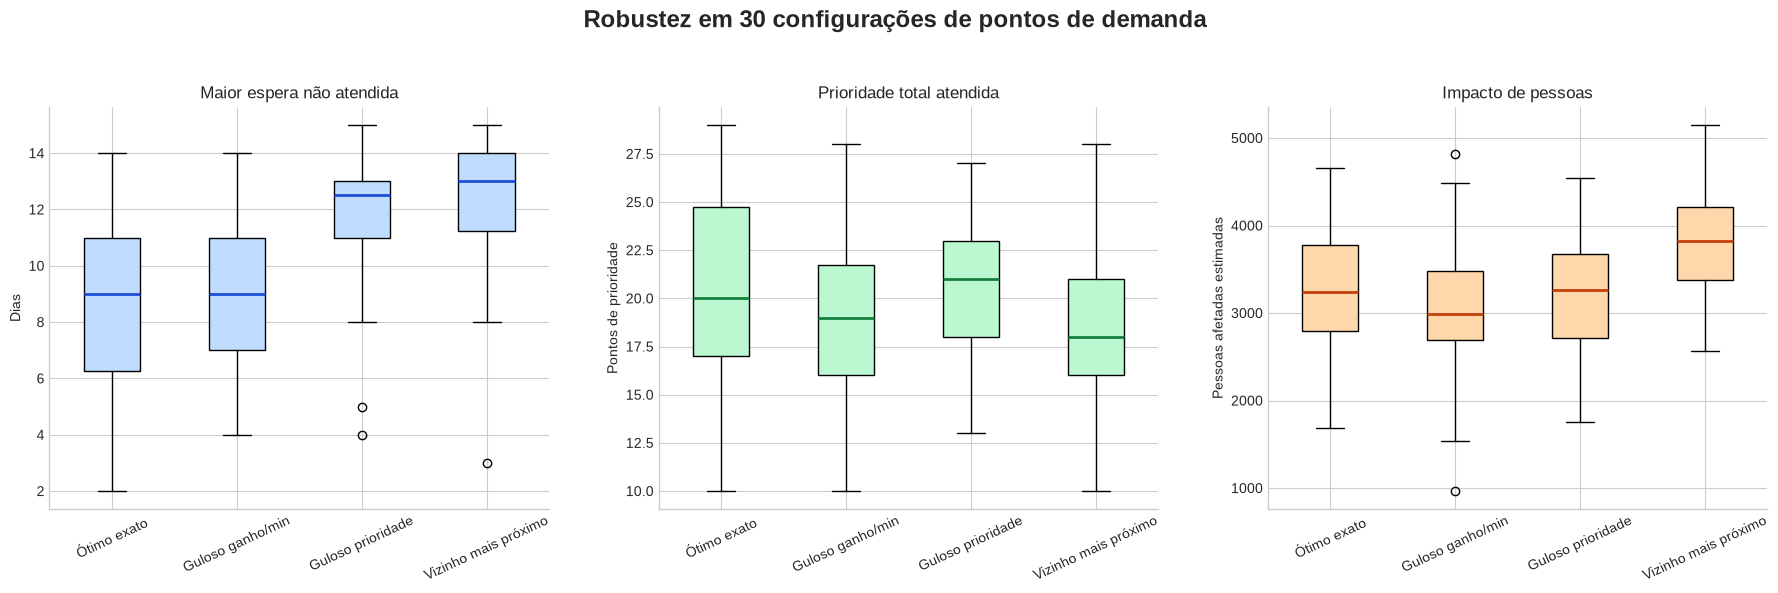

In [14]:
plot_order = list(method_labels.values())
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

waiting_data = [experiments_df.loc[experiments_df["algoritmo"] == name, "maior_espera_nao_atendida_dias"] for name in plot_order]
axes[0].boxplot(waiting_data, tick_labels=plot_order, patch_artist=True, boxprops={"facecolor": "#bfdbfe"}, medianprops={"color": "#1d4ed8", "linewidth": 2})
axes[0].set_title("Maior espera não atendida")
axes[0].set_ylabel("Dias")
axes[0].tick_params(axis="x", rotation=25)

priority_data = [experiments_df.loc[experiments_df["algoritmo"] == name, "prioridade_atendida"] for name in plot_order]
axes[1].boxplot(priority_data, tick_labels=plot_order, patch_artist=True, boxprops={"facecolor": "#bbf7d0"}, medianprops={"color": "#15803d", "linewidth": 2})
axes[1].set_title("Prioridade total atendida")
axes[1].set_ylabel("Pontos de prioridade")
axes[1].tick_params(axis="x", rotation=25)

people_data = [experiments_df.loc[experiments_df["algoritmo"] == name, "pessoas_afetadas"] for name in plot_order]
axes[2].boxplot(people_data, tick_labels=plot_order, patch_artist=True, boxprops={"facecolor": "#fed7aa"}, medianprops={"color": "#c2410c", "linewidth": 2})
axes[2].set_title("Impacto de pessoas")
axes[2].set_ylabel("Pessoas afetadas estimadas")
axes[2].tick_params(axis="x", rotation=25)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"Robustez em {N_SCENARIOS} configurações de pontos de demanda", fontsize=17, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94], w_pad=3.0)
fig.savefig(OUTPUT_DIR / "experimentos_multiplas_instancias.png", dpi=170, bbox_inches="tight")
plt.show()


## 12. Leitura dos novos resultados

Nos 30 cenários, o ótimo exato com os pesos fixos calibrados teve **8,43 dias de maior espera média**, contra 9,10 do guloso por ganho/minuto, 11,77 do guloso por prioridade e 12,57 do vizinho mais próximo.

Na prioridade, o ótimo atingiu **20,40 pontos em média**, praticamente empatado com o guloso por prioridade, que atingiu 20,57. No impacto populacional, afetou em média **3.295 pessoas**: menos que o vizinho mais próximo (3.836), próximo do guloso por prioridade (3.225), mas acima do guloso por ganho/minuto (3.026).

A configuração 0,55/0,20/0,25 oferece um compromisso equilibrado entre os três critérios, sem trocar os pesos entre cenários. O pior caso de espera ainda chegou a 14 dias; se esse valor precisar ser uma garantia, será necessária uma restrição de prazo máximo, pois a calibração de pesos sozinha não elimina o pior caso.